In [101]:
from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn._vf import MLPUnconditionalVF
import matplotlib.pyplot as plt
# from sc_flow.backends.torch.methods import BaseMethod

In [ ]:
from abc import ABC, abstractmethod
from collections.abc import Callable
from typing import Any

import torch
from torch import nn

import sc_flow.methods as basemethods
from sc_flow.backends.torch._types import TensorLike
from sc_flow.backends.torch.nn._vf import BaseVelocityField
from sc_flow.backends.torch.probability_paths import BaseProbabilityPath

__all__ = ["BaseMethod"]


class Solver(ABC, nn.Module):
    """Abstract Base Class for Solvers"""

    @abstractmethod
    def solve(self, vf, source: torch.Tensor | None = None, **kwargs: Any) -> torch.Tensor:
        """Solve method to be implemented by subclasses."""
        pass


LinTerm = tuple[torch.Tensor, torch.Tensor]
QuadTerm = tuple[torch.Tensor, torch.Tensor, torch.Tensor | None, torch.Tensor | None]
GENOTDataMatchFn = Callable[[LinTerm], torch.Tensor] | Callable[[QuadTerm], torch.Tensor]


class BaseMethod(basemethods.FlowMatching):
    """TODO."""

    def __init__(
        self,
        vf: BaseVelocityField,
        probability_path: BaseProbabilityPath,
        time_sampler: Callable[[int], torch.Tensor],  # [[int], np.ndarray],
        solver: Solver | Any,
        match_fn: Any,  # TODO: adapt type
        ema: int = 1,
        generate_from_noise: bool = False,
        opt: Any = None,
        control_key: str | None = None,
        noise_distribution: Callable[[tuple[int, ...]], torch.Tensor] | None = None,
        **kwargs: Any,  # TODO Add parcing of kwargs
    ):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.ema = ema
        self.generate_from_noise = generate_from_noise
        self.control_key = control_key
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self.solver = solver
        self.noise_distribution = noise_distribution or (lambda shape: torch.randn(size=shape))
        # TODO: add cfg

        self._is_trained = False
        self.vf_step_fn = self._get_vf_step_fn()

    @staticmethod
    def _prepare_data(
        batch: dict[str, Any],  # TODO adapt type
    ) -> tuple[
        tuple[torch.Tensor, torch.Tensor],
        tuple[torch.Tensor | None, ...],
    ]:
        """TODO"""
        src_lin, src_quad = batch.get("src_cell_data"), batch.get("src_cell_data_quad")
        tgt_lin, tgt_quad = batch.get("tgt_cell_data"), batch.get("tgt_cell_data_quad")

        if src_quad is None and tgt_quad is None:  # lin
            source, target = src_lin, tgt_lin
            arrs = src_lin, tgt_lin
        elif src_lin is None and tgt_lin is None:  # quad
            source, target = src_quad, tgt_quad
            arrs = src_quad, tgt_quad
        elif all(arr is not None for arr in (src_lin, tgt_lin, src_quad, tgt_quad)):  # fused quad
            source = torch.concat([src_lin, src_quad], dim=1)
            target = torch.concat([tgt_lin, tgt_quad], dim=1)
            arrs = src_quad, tgt_quad, src_lin, tgt_lin
        else:
            raise RuntimeError("Cannot infer OT problem type from data.")

        return (source, target), arrs  # type: ignore[return-value]

    def step_fn(
        self,
        batch: dict[str, Any],  # TODO Adapt types
    ) -> torch.Tensor:
        """Single step function of the solver.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, torch.Tensor]
        """
        condition = batch.get("condition")
        (source, target), matching_data = self._prepare_data(batch)
        n = source.shape[0]
        time = self.time_sampler(n)

        src_ixs, tgt_ixs = self.match_fn(*matching_data)

        source, target = source[src_ixs], target[tgt_ixs]
        loss = self.vf_step_fn(
            time,
            source,
            target,
            condition,
        )
        return loss

    def _get_vf_step_fn(self):
        def vf_step_fn(
            time: torch.Tensor,
            source: torch.Tensor,
            target: torch.Tensor,
            conditions: dict[str, torch.Tensor] | Any,
        ):
            def loss_fn(
                t: torch.Tensor,
                source: torch.Tensor,
                target: torch.Tensor,
                conditions: dict[str, torch.Tensor],
            ) -> torch.Tensor:
                if self.generate_from_noise:
                    latent = self.noise_distribution(target.shape)
                    x_t = self.probability_path.compute_xt(t, latent, target)
                    if self.control_key is not None:
                        conditions = conditions.copy()
                        conditions[self.control_key] = source
                else:
                    x_t = self.probability_path.compute_xt(t, source, target)
                v_t = self.vf(
                    t,
                    x_t,
                    conditions,
                    source,
                )
                u_t = self.probability_path.compute_ut(t, x_t, source, target)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            with torch.autocast("cuda"):
                loss = loss_fn(time, source, target, conditions)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def train_step(
        self,
        batch: dict[str, TensorLike],
        prng_key,
    ) -> float:
        """Training step of the method.

        :param batch: Data batch with keys ``src_cell_data``, ``tgt_cell_data``, and
            ``condition``.
        :type batch: dict[str, TensorLike]

        :param rng_step_fn: Random number generator for the step function. Default is None.
        :type rng_step_fn: TensorLike | None, optional
        """
        loss = self.step_fn(batch)
        return float(loss.cpu())

    def get_condition_embedding(self, condition: dict[str, torch.Tensor], return_as_numpy=True) -> torch.Tensor:
        """"""  # noqa
        pass

    def predict(
        self,
        x: torch.Tensor | dict[str, torch.Tensor],
        condition: dict[str, torch.Tensor] | None = None,
        rng: torch.Tensor | None = None,
        rng_genot: torch.Tensor | None = None,
        batched: bool = False,
        **kwargs: Any,
    ) -> torch.Tensor | tuple[torch.Tensor, TensorLike] | dict[str, torch.Tensor]:
        """Generate the push-forward of ``x`` under condition ``condition``.

        This function solves the ODE learnt with
        the :class:`~cellflow.networks.ConditionalVelocityField`.

        Parameters
        ----------
        x
            Input data of shape [batch_size, ...].
        condition
            Condition of the input data of shape [batch_size, ...].
        rng
            Random number generator to sample from the latent distribution,
            only used if ``condition_mode='stochastic'``. If :obj:`None`, the
            mean embedding is used.
        rng_genot
            Random generate used to sample from the latent distribution in cell space.
        batched
            Whether to use batched prediction. This is only supported if the input has
            the same number of cells for each condition. For example, this works when using
            :class:`~cellflow.data.ValidationSampler` to sample the validation data.
        kwargs
            Keyword arguments for :func:`diffrax.diffeqsolve`.

        Returns
        -------
        The push-forward distribution of ``x`` under condition ``condition``.
        """
        if batched and not x:
            return {}

        if batched:
            if isinstance(x, dict):
                keys = sorted(x.keys())
            if condition is not None:
                condition_keys = sorted(set().union(*(condition[k].keys() for k in keys)))

            # assert that the number of cells is the same for each condition
            n_cells = x[keys[0]].shape[0]
            for k in keys:
                assert x[k].shape[0] == n_cells, "The number of cells must be the same for each condition"
            src_inputs = torch.stack([x[k] for k in keys], axis=0)
            batched_conditions = {}
            for cond_key in condition_keys:
                batched_conditions[cond_key] = torch.stack([condition[k][cond_key] for k in keys])
            pred_targets = self._predict_step(x=src_inputs, condition=batched_conditions)
            return {k: pred_targets[i] for i, k in enumerate(keys)}
        else:
            if isinstance(x, dict):
                raise TypeError(f"State `x` should be of type `torch.Tensor` and not `{type(x)}`")
            x_pred = self._predict_step(x, condition)
            return x_pred

    def _predict_step(self, x, condition, time=None, **kwargs) -> torch.Tensor:
        if not time:
            time = torch.linspace(0.0, 1.0, 101)

        x_pred = self.solver.solve(
            self.vf,
            source=x,
            time=time,
            vf_kwargs={"condition_dict": condition},
            rtol=1e-6,
            atol=1e-7,
            return_trajectory=False,
        )
        print(x_pred.shape)
        return x_pred

In [163]:
from typing import Any, Literal

from torch import Tensor, device
from torchdiffeq import odeint

from sc_flow.backends.torch.nn._vf import BaseVelocityField

from abc import ABC, abstractmethod
from typing import Any

from torch import nn


class Solver(ABC, nn.Module):
    """Abstract Base Class for Solvers"""

    @abstractmethod
    def solve(self, *, source: Tensor | None = None, **kwargs: Any) -> Tensor:
        """Solve method to be implemented by subclasses."""
        ...


class ODESolver(Solver):
    r"""Class for solving deterministic ordinary differential equations (ODEs) with :func:`torchdiffeq.odeint`.

    :param method: (Optional) Integration scheme used by ``torchdiffeq``. Defaults to ``"euler"``. Other valid options depend on ``torchdiffeq``.
    :type method: class:`str`

    :param device_id: (Optional) Identifier for the target compute device. Choices are ``"cpu"`` or ``"cuda"``. Defaults to ``"cpu"``.
    :type device_id: class:`Literal["cuda", "cpu"]`
    """

    def __init__(
        self,
        method: str = "euler",
        device_id: Literal["cuda", "cpu"] = "cpu",
    ) -> None:
        super().__init__()
        self.method = method
        self.device = device(device_id)

    def solve(
        self,
        vf: BaseVelocityField,
        source: Tensor,
        time: Tensor,
        *,
        rtol: float,
        atol: float,
        vf_kwargs: dict[str, Any] | None = None,
        solver_kwargs: dict[str, Any] | None = None,
        return_trajectory: bool = True,
    ) -> Tensor:
        r"""Integrates the ODE defined by the provided velocity field.

        :param vf: Velocity field providing the time-dependent dynamics. Must implement :meth:`BaseVelocityField.get_vf_fn`.
        :type vf: class:`BaseVelocityField`

        :param source: Initial state of the ODE.
        :type source: class:`torch.Tensor`

        :param time: Time grid over which to integrate the ODE.
        :type time: class:`torch.Tensor`

        :param rtol: Relative tolerance for the ODE solver.
        :type rtol: class:`float`

        :param atol: Absolute tolerance for the ODE solver.
        :type atol: class:`float`

        :param vf_kwargs: (Optional) Keyword arguments passed to
            :meth:`BaseVelocityField.get_vf_fn`.
        :type vf_kwargs: class:`dict[str, Any] | None`

        :param solver_kwargs: (Optional) Keyword arguments forwarded directly to
            :func:`torchdiffeq.odeint`.
        :type solver_kwargs: class:`dict[str, Any] | None`

        :param return_trajectory: When ``True``, returns the full trajectory, else returns only the final state at the last time point.
        :type return_trajectory: class:`bool`

        :returns: Either the full state trajectory or the final state depending on
            :param:`return_trajectory`.
        :rtype: class:`torch.Tensor`
        """
        if solver_kwargs is None:
            solver_kwargs = {}

        if vf_kwargs is None:
            vf_kwargs = {}

        diff_eqn = vf.get_vf_fn(**vf_kwargs)

        source = source.to(self.device)
        time = time.to(self.device)

        trajectory = odeint(
            diff_eqn,
            source,
            time,
            rtol=rtol,
            atol=atol,
            method=self.method,
            **solver_kwargs,
        )

        if return_trajectory:
            return trajectory
        else:
            return trajectory[-1]

In [164]:
def dummy_time_sampler(n):
    return torch.rand(size=(n,))

In [165]:
import logging
from collections.abc import Callable
from typing import Literal

import numpy as np
import torch

logger = logging.getLogger(__name__)


def independent_coupling(
    source: torch.Tensor,
    target: torch.Tensor,
) -> tuple[np.ndarray, np.ndarray]:
    """Matches the :param:`source` and :param:`target` groups and returns the respective indices.

    :param source: A tensor of values containing the data coming from the source distribution.
    :type source: class:`torch.Tensor`

    :param target: A tensor of values containing the data coming from the target distribution.
    :type target: class:`torch.Tensor`

    Returns
    -------
    ## TODO
    """
    # randomy permuting the tensors
    src_random_perm_idx = np.random.choice(np.arange(source.shape[0]), size=source.shape[0], replace=False)
    tgt_random_perm_idx = np.random.choice(np.arange(target.shape[0]), size=source.shape[0], replace=False)

    min_shape = min(src_random_perm_idx.shape[0], tgt_random_perm_idx.shape[0])

    return src_random_perm_idx[:min_shape], tgt_random_perm_idx[:min_shape]

In [ ]:
from sc_flow.backends.torch.probability_paths import LinearDiracProbabilityPath

vf = MLPUnconditionalVF(state_dim=2, encode_state=True, encode_time=True, time_features_id="torch-cfm")
print(vf)
opt = torch.optim.AdamW

prob_path = LinearDiracProbabilityPath(sigma=0.0)
solver = ODESolver()

MLPUnconditionalVF(
  (_vf): ModuleDict(
    (time_features): FunctionalModule(
      (_identity): Identity()
    )
    (time_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=256, out_features=16, bias=True)
          (activation): Identity()
        )
      )
    )
    (state_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=2, out_features=32, bias=True)
          (activation): Identity()
        )
      )
    )
    (conditioning_layer): ConcatConditioning(
      (_identity): Identity()
    )
    (vf_decoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=48, out_features=2, bias=True)
          (activation): Identity()
        )
      )
    )
  )
)


In [167]:
cfm = BaseMethod(
    vf=vf,
    probability_path=prob_path,
    time_sampler=dummy_time_sampler,
    solver=solver,
    match_fn=independent_coupling,
    opt=opt,
)

In [168]:
trainer = FlowTrainer(
    method=cfm,
    require_prng=False,
)

In [169]:
input_dim = 2
output_dim = 2
hidden_dims = (20, 20)
batch_size = 32
offset = 4.0


class DummyTrainLoaderTorch:
    def __init__(self):
        self.sample_calls = 0

    def sample(self, _):
        from torch import randn

        self.sample_calls += 1
        return {
            "src_cell_data": randn((batch_size, output_dim)),
            "tgt_cell_data": randn((batch_size, output_dim)) + offset,
        }

In [170]:
train_loader = DummyTrainLoaderTorch()

In [179]:
input_dim = 2
output_dim = 2
hidden_dims = (20, 20)
batch_size = 500
data = DummyTrainLoaderTorch().sample(None)

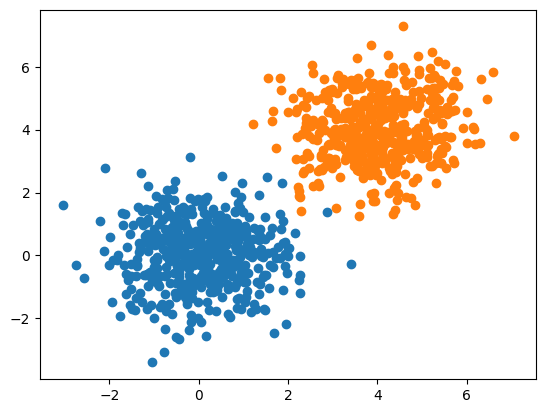

In [172]:
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])

In [173]:
train_loader

In [174]:
trainer.fit(train_dataloader=train_loader, num_iterations=10_000, valid_freq=10000)

  0%|                                                                                                                            | 0/10000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.
/Users/mariia.minaeva/envs/sc_flow_tools/lib/python3.12/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:09<00:00, 1043.18it/s]


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

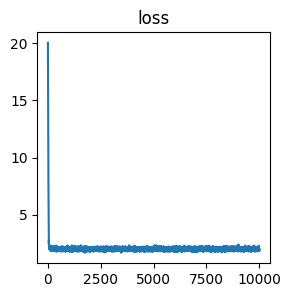

In [175]:
trainer.plot_training_logs()

In [176]:
x = torch.rand((batch_size, output_dim))

In [177]:
preds = trainer._method.predict(data["src_cell_data"])

torch.Size([500, 2])


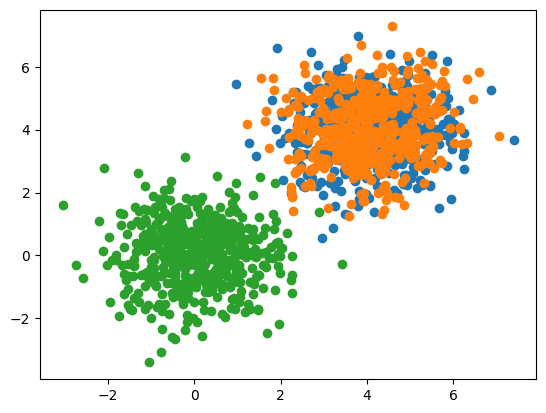

In [178]:
plt.scatter(preds[:, 0].detach().numpy(), preds[:, 1].detach().numpy())
plt.scatter(data["tgt_cell_data"][:, 0], data["tgt_cell_data"][:, 1])
plt.scatter(data["src_cell_data"][:, 0], data["src_cell_data"][:, 1])